<a href="https://colab.research.google.com/github/athuladev/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal%20Agriculture%20Performance%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Upload dataset

In [ ]:
# ============================================
# SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# ============================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Upload CSV file
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


2. Load the dataset

In [ ]:
# Read the uploaded CSV file

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


3. Understand the dataset

In [ ]:
# Dataset information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                    

4. Statistical summary

In [ ]:
# Statistical summary of numerical columns

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


5. Check missing values

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': (missing_values / len(df)) * 100
})

missing_table = missing_table[missing_table['Missing Values'] > 0]

display(missing_table)

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


6. Visualize missing values

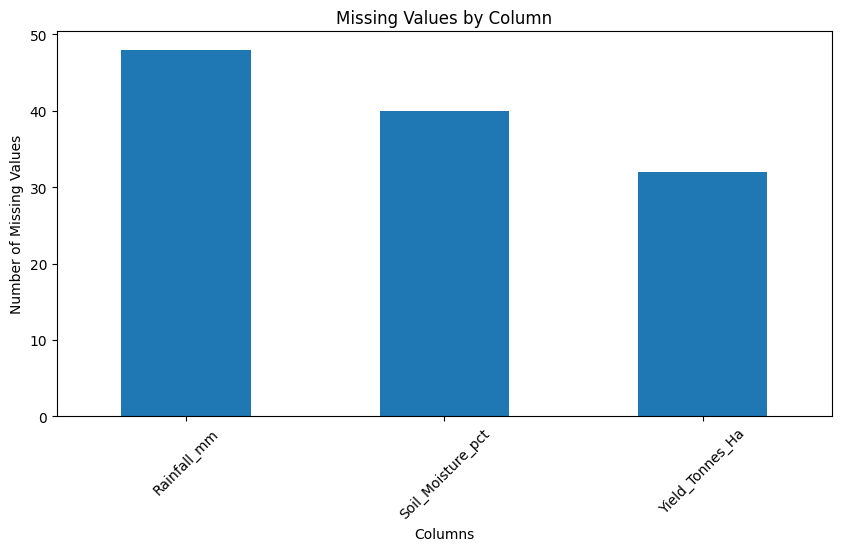

In [ ]:
plt.figure(figsize=(10, 5))

missing_values[missing_values > 0].plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

7. Data cleaning

In [ ]:
# Make a copy of the dataset

data = df.copy()

# Numerical columns
numeric_columns = data.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for column in numeric_columns:
    data[column] = data[column].fillna(data[column].median())

print("Missing values after cleaning:")

print(data.isnull().sum().sum())

Missing values after cleaning:
0


8. Check duplicate records

In [ ]:
# Check duplicate rows

duplicates = data.duplicated().sum()

print("Number of duplicate rows:", duplicates)

# Remove duplicates
data = data.drop_duplicates()

print("Dataset shape after removing duplicates:", data.shape)

Number of duplicate rows: 0
Dataset shape after removing duplicates: (4000, 28)


9. Explore categorical variables

In [ ]:
# Display unique values

categorical_columns = data.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n", column)
    print(data[column].value_counts())


 Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: 

10. Season distribution

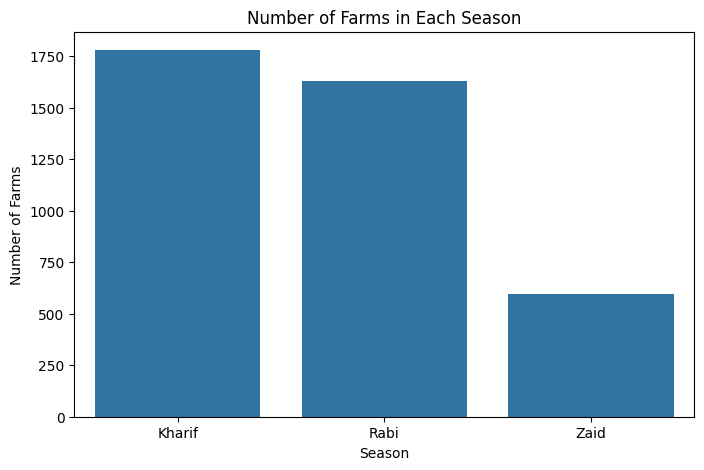

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x='Season')

plt.title('Number of Farms in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

11. Agricultural performance across seasons

In [ ]:
# Average agricultural performance by season

season_performance = data.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

display(season_performance)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,4.41,38.22


12. Yield by season

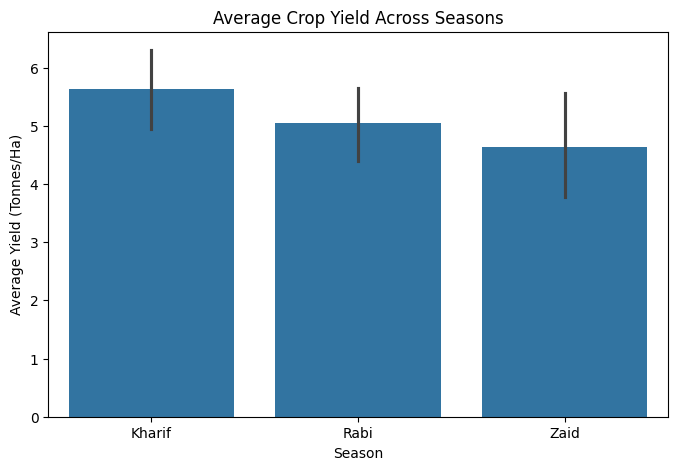

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

13. Profit by season

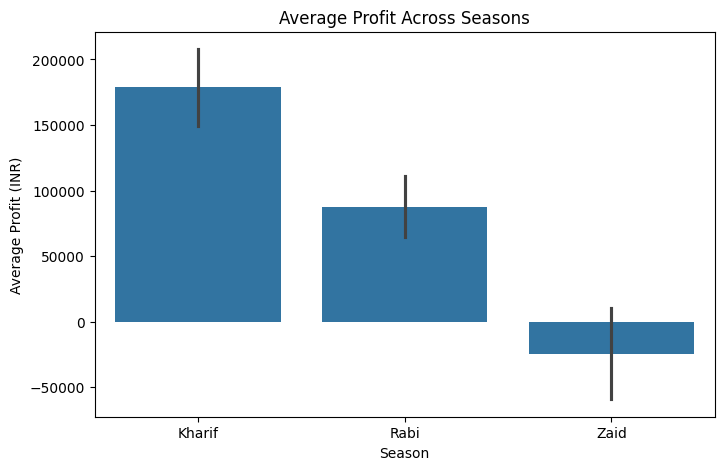

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

14. Production by season

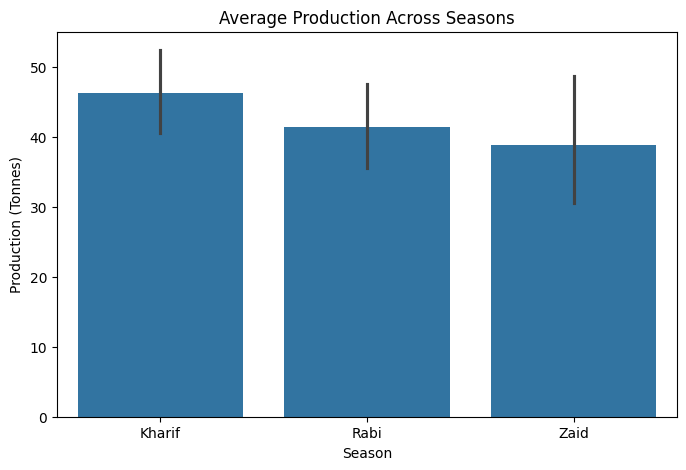

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='Season',
    y='Production_Tonnes',
    estimator='mean'
)

plt.title('Average Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.show()

15. Environmental conditions across seasons

In [ ]:
environmental = data.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

display(environmental)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


16. Rainfall by season

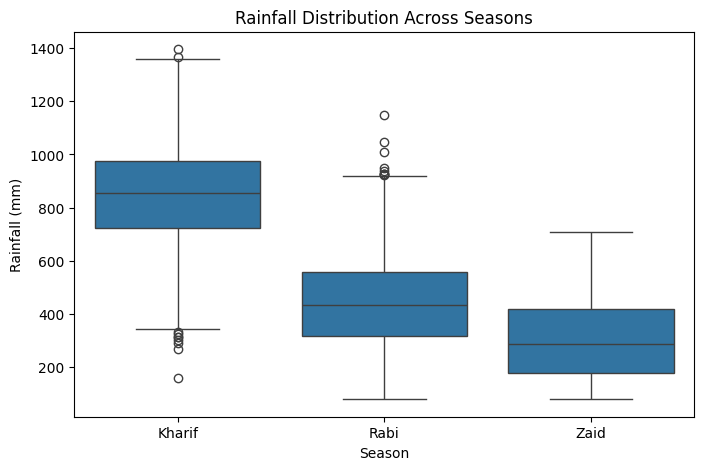

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Season',
    y='Rainfall_mm'
)

plt.title('Rainfall Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

17. Temperature by season

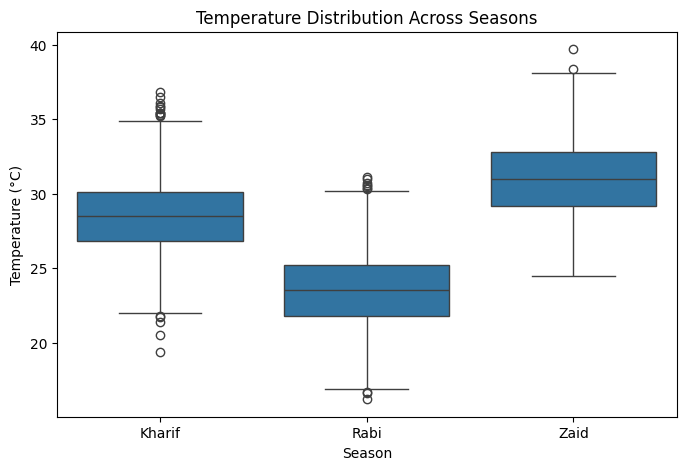

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title('Temperature Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')

plt.show()

18. Resource usage across seasons

In [ ]:
resource_usage = data.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean',
    'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean'
}).round(2)

display(resource_usage)

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,187.08,5.08,6102.20,120.02,58.10,105.30
Rabi,185.41,5.02,5846.99,120.40,57.31,103.93
Zaid,184.64,5.17,6419.89,120.53,58.13,105.42


19. Water usage

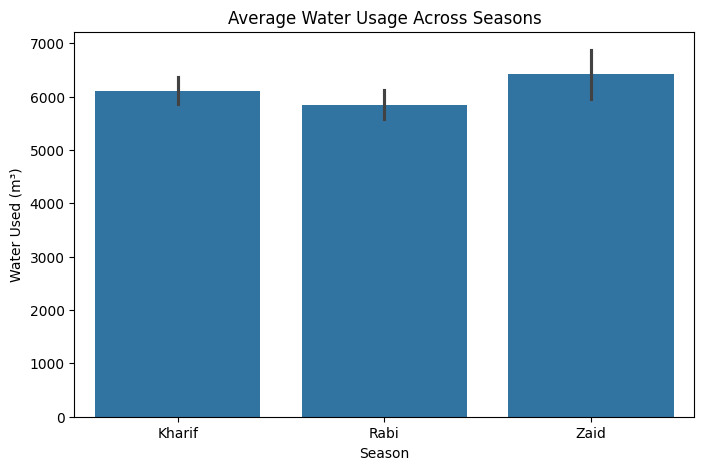

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='Season',
    y='Water_Used_m3',
    estimator='mean'
)

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.show()

20. Water efficiency

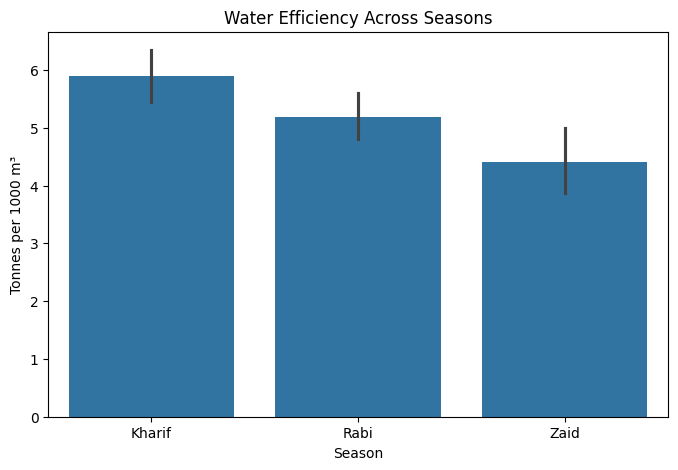

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean'
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')

plt.show()

21. Irrigation method analysis

In [ ]:
irrigation_season = pd.crosstab(
    data['Season'],
    data['Irrigation_Method']
)

display(irrigation_season)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


<Figure size 1000x600 with 0 Axes>

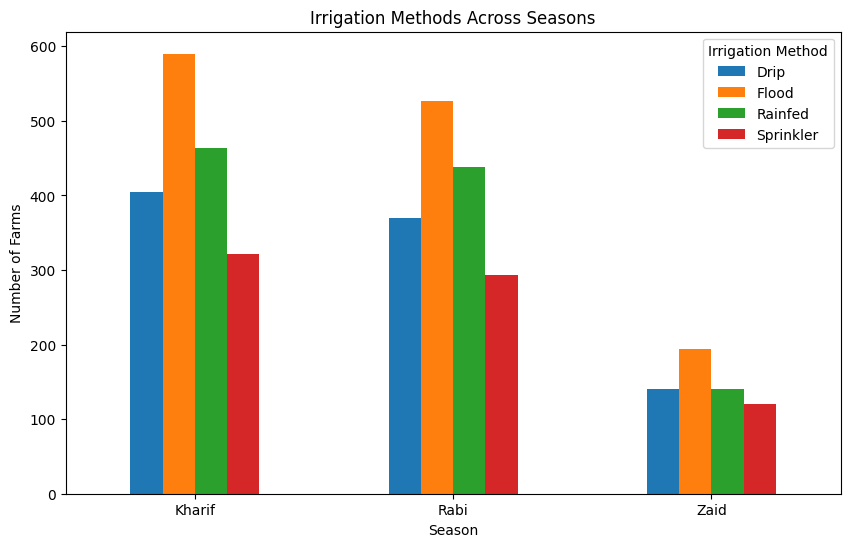

In [ ]:
plt.figure(figsize=(10, 6))

irrigation_season.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Irrigation Methods Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')

plt.show()

22. Irrigation method vs yield

In [ ]:
irrigation_yield = data.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).round(2)

display(irrigation_yield)

,Yield_Tonnes_Ha,Production_Tonnes,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,57.99,6.27,219626.00
Flood,4.86,38.73,3.44,73354.02
Rainfed,4.60,36.61,7.56,79050.37
Sprinkler,5.16,42.34,4.67,91121.08


23. Crop-wise performance

In [ ]:
crop_performance = data.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
).round(2)

display(crop_performance)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Disease_Pest_Risk_pct
Crop,,,,,,
Sugarcane,46.64,392.41,1371980.11,554792.13,817187.99,45.40
Maize,2.71,21.78,457067.99,541046.32,-83978.33,45.54
Rice,2.43,19.29,423615.26,525828.76,-102213.50,46.50
Wheat,2.11,16.85,400104.89,523503.22,-123398.34,47.85
Chilli,1.54,12.38,1276777.23,525898.89,750878.34,46.06
Groundnut,1.32,9.66,542935.50,498077.38,44858.12,46.29
Cotton,1.23,9.40,639423.08,514876.17,124546.92,45.97
Pulses,0.92,7.40,528465.87,532703.92,-4238.05,46.57


24. Crop yield visualization

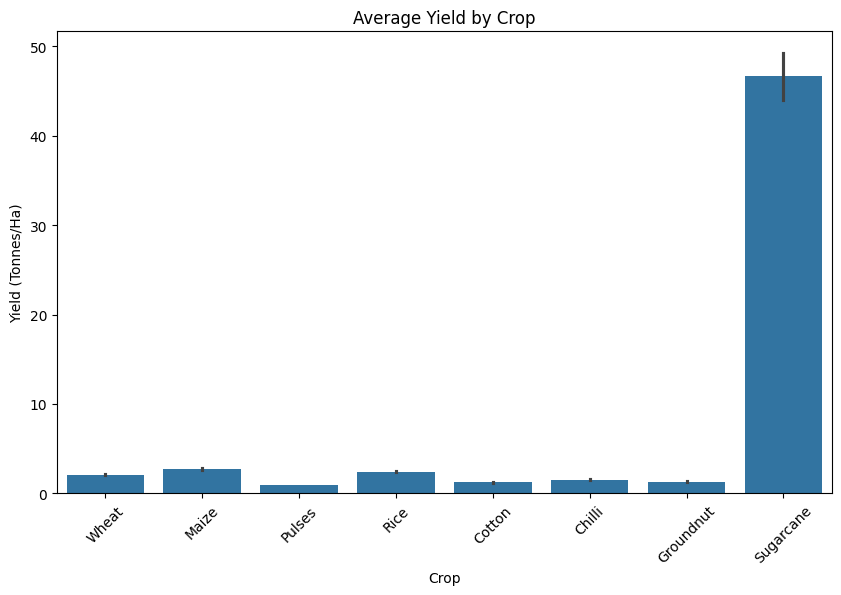

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x='Crop',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')

plt.xticks(rotation=45)
plt.show()

25. Crop and season comparison

In [ ]:
crop_season_yield = data.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


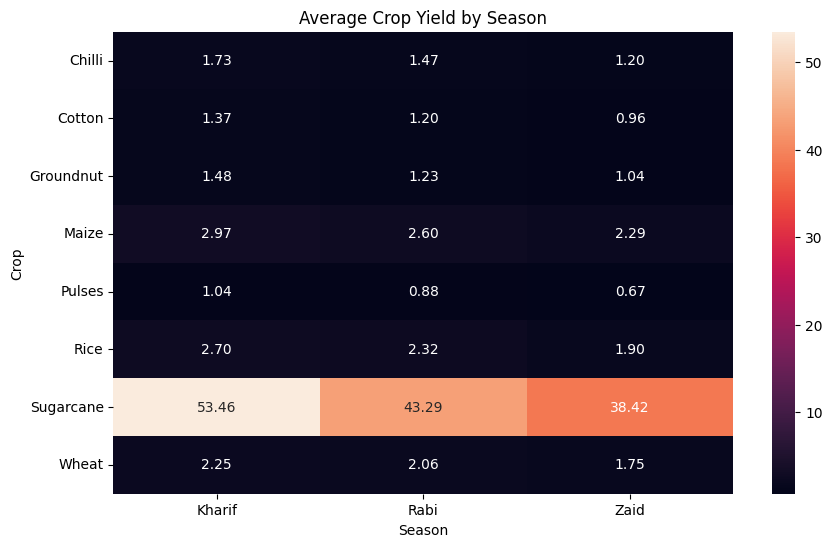

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

26. Economic performance

In [ ]:
economic_performance = data.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

display(economic_performance)

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


27. Revenue vs cost

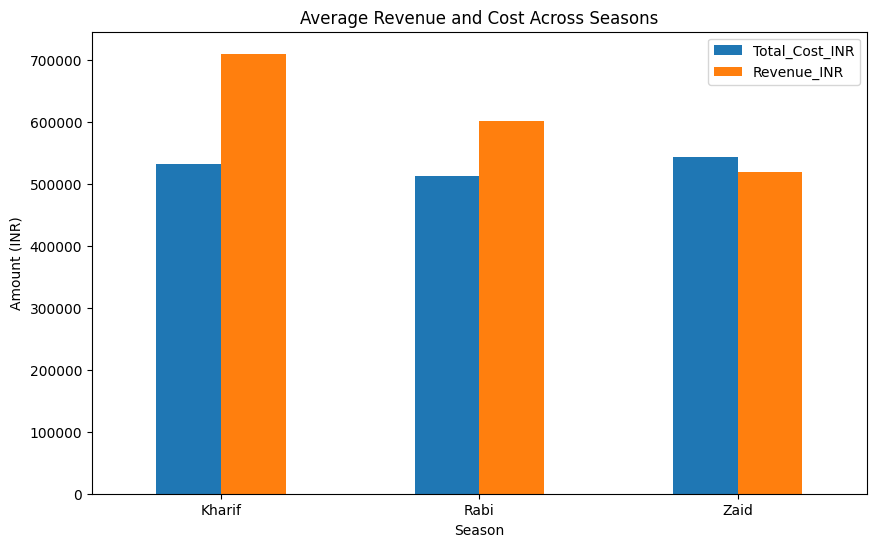

In [ ]:
economic_plot = data.groupby('Season')[[
    'Total_Cost_INR',
    'Revenue_INR'
]].mean()

economic_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Revenue and Cost Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')

plt.xticks(rotation=0)
plt.show()

28. Disease and pest risk

In [ ]:
risk = data.groupby('Season').agg({
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

display(risk)

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


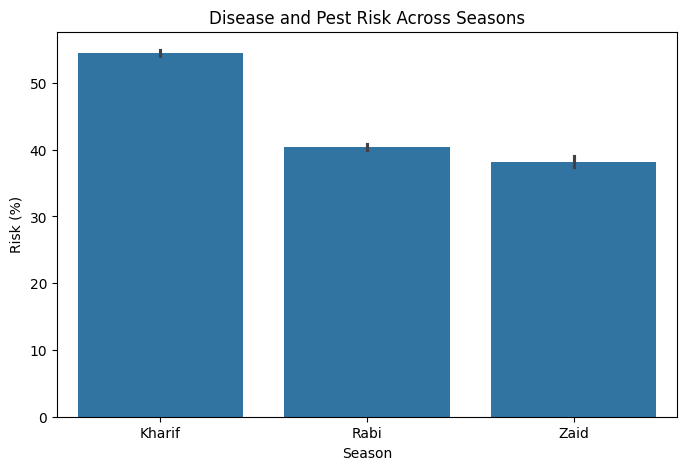

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='Season',
    y='Disease_Pest_Risk_pct',
    estimator='mean'
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.show()

29. Correlation analysis

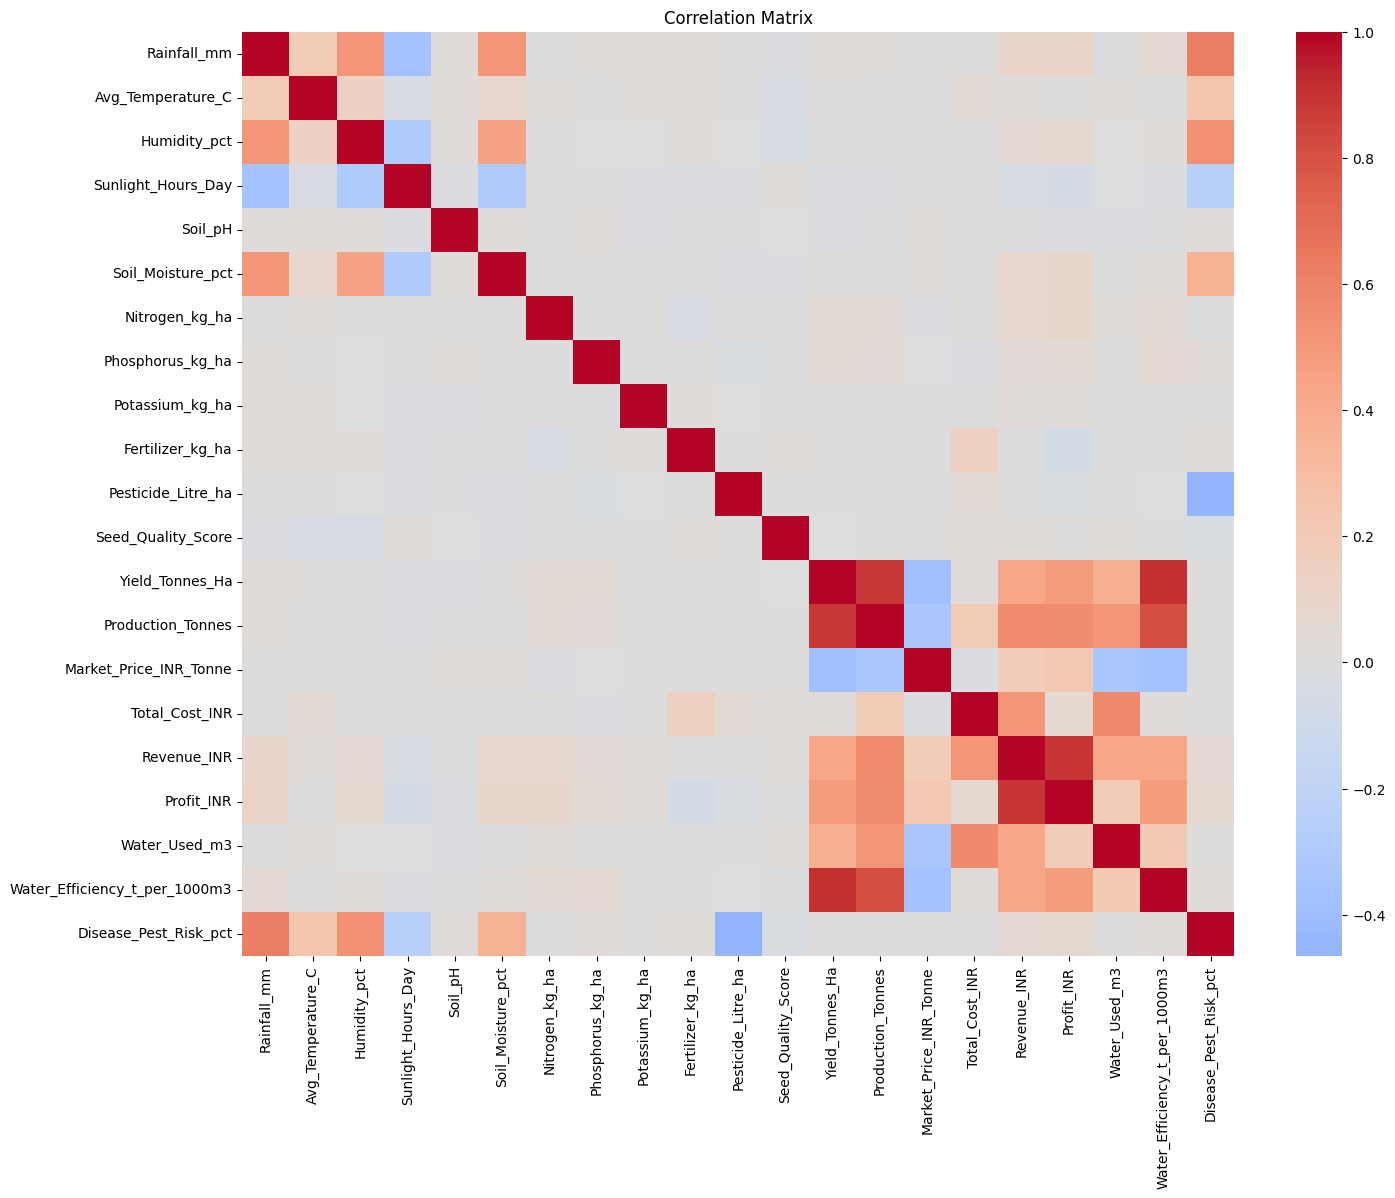

In [ ]:
# Select important numerical variables

correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

corr = data[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.show()

30. Find factors most related to yield

In [ ]:
yield_corr = corr['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

display(yield_corr)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


31. Find factors most related to profit

In [ ]:
profit_corr = corr['Profit_INR'].sort_values(
    ascending=False
)

display(profit_corr)

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281
Nitrogen_kg_ha,0.085016


32. Rainfall vs yield

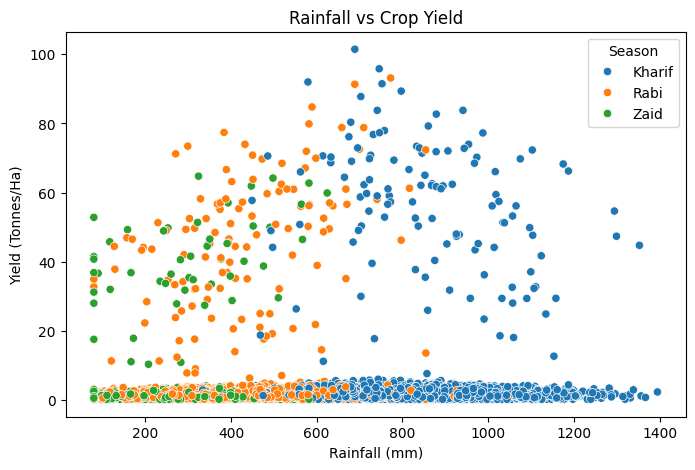

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

33. Temperature vs yield

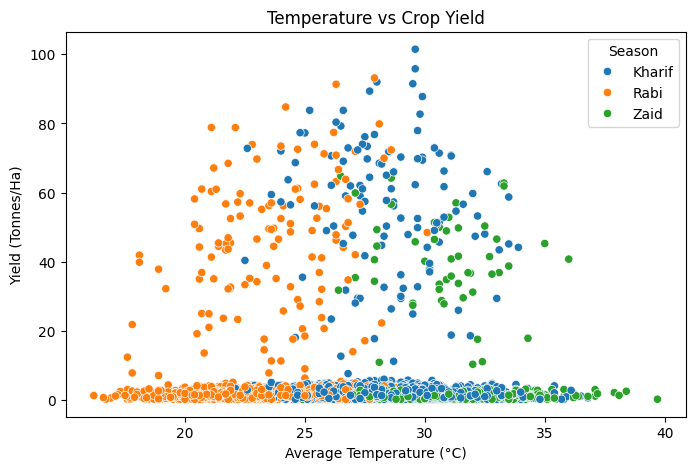

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

34. Soil moisture vs yield

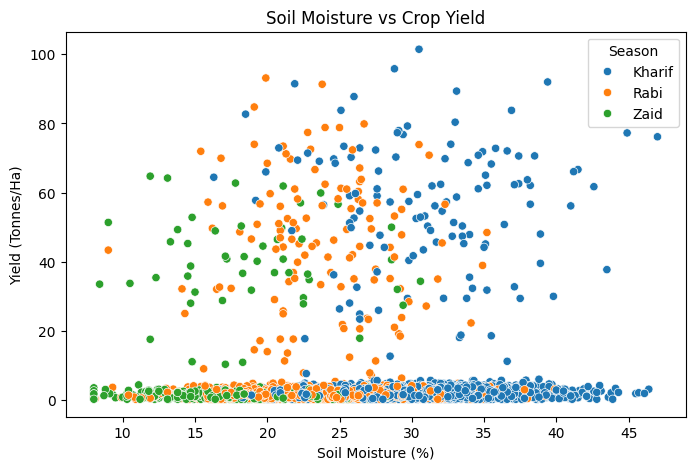

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Soil Moisture vs Crop Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

35. Statistical test: Does yield differ between seasons?

In [ ]:
# Separate yield values by season

season_groups = [
    group['Yield_Tonnes_Ha'].values
    for name, group in data.groupby('Season')
]

# One-way ANOVA

anova_result = stats.f_oneway(*season_groups)

print("ANOVA Statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("\nResult: Yield differs significantly across seasons.")
else:
    print("\nResult: No statistically significant difference in yield across seasons.")

ANOVA Statistic: 1.5438804542488311
P-value: 0.21367813841792296

Result: No statistically significant difference in yield across seasons.


36. Statistical test: Profit across seasons

In [ ]:
profit_groups = [
    group['Profit_INR'].values
    for name, group in data.groupby('Season')
]

anova_profit = stats.f_oneway(*profit_groups)

print("ANOVA Statistic:", anova_profit.statistic)
print("P-value:", anova_profit.pvalue)

if anova_profit.pvalue < 0.05:
    print("\nResult: Profit differs significantly across seasons.")
else:
    print("\nResult: No statistically significant difference in profit across seasons.")

ANOVA Statistic: 34.29175033935195
P-value: 1.7124156677360182e-15

Result: Profit differs significantly across seasons.


37. Regional analysis

In [ ]:
state_performance = data.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
).round(2)

display(state_performance)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,
Punjab,6.12,52.23,136025.64,5.62,46.00
Karnataka,5.69,47.73,119422.34,5.56,46.06
Gujarat,5.66,48.33,117568.24,5.58,45.95
Telangana,5.04,39.25,108829.62,5.46,46.36
Maharashtra,5.02,43.98,135428.86,5.28,46.44
Madhya Pradesh,4.99,37.56,86840.76,5.27,47.08
Tamil Nadu,4.88,40.84,117744.75,5.31,46.28
Andhra Pradesh,4.63,36.91,73453.53,5.03,46.72


38. Best-performing states

In [ ]:
top_states = state_performance.head(10)

display(top_states)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,
Punjab,6.12,52.23,136025.64,5.62,46.00
Karnataka,5.69,47.73,119422.34,5.56,46.06
Gujarat,5.66,48.33,117568.24,5.58,45.95
Telangana,5.04,39.25,108829.62,5.46,46.36
Maharashtra,5.02,43.98,135428.86,5.28,46.44
Madhya Pradesh,4.99,37.56,86840.76,5.27,47.08
Tamil Nadu,4.88,40.84,117744.75,5.31,46.28
Andhra Pradesh,4.63,36.91,73453.53,5.03,46.72


39. Best-performing crops

In [ ]:
top_crops = crop_performance.sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

display(top_crops)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Disease_Pest_Risk_pct
Crop,,,,,,
Sugarcane,46.64,392.41,1371980.11,554792.13,817187.99,45.40
Maize,2.71,21.78,457067.99,541046.32,-83978.33,45.54
Rice,2.43,19.29,423615.26,525828.76,-102213.50,46.50
Wheat,2.11,16.85,400104.89,523503.22,-123398.34,47.85
Chilli,1.54,12.38,1276777.23,525898.89,750878.34,46.06
Groundnut,1.32,9.66,542935.50,498077.38,44858.12,46.29
Cotton,1.23,9.40,639423.08,514876.17,124546.92,45.97
Pulses,0.92,7.40,528465.87,532703.92,-4238.05,46.57


40. Identify unusual observations

In [ ]:
# Identify farms with unusually high or low yield

Q1 = data['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = data['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = data[
    (data['Yield_Tonnes_Ha'] < lower_limit) |
    (data['Yield_Tonnes_Ha'] > upper_limit)
]

print("Number of unusual yield observations:", len(outliers))

display(outliers[
    ['Farm_ID', 'State', 'Crop', 'Season',
     'Yield_Tonnes_Ha', 'Profit_INR']
].head(20))

Number of unusual yield observations: 302


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Profit_INR
47,SF10048,Punjab,Sugarcane,Zaid,36.69,556688
75,SF10076,Maharashtra,Sugarcane,Kharif,62.58,1675730
79,SF10080,Karnataka,Sugarcane,Zaid,33.55,691166
82,SF10083,Andhra Pradesh,Sugarcane,Rabi,49.52,279221
92,SF10093,Gujarat,Sugarcane,Kharif,70.23,2427692
113,SF10114,Tamil Nadu,Sugarcane,Rabi,58.06,2324331
132,SF10133,Telangana,Sugarcane,Kharif,29.47,89113
154,SF10155,Telangana,Sugarcane,Kharif,47.88,798280
155,SF10156,Madhya Pradesh,Sugarcane,Kharif,62.09,573019
164,SF10165,Telangana,Sugarcane,Rabi,36.91,297233


41. Machine Learning model for yield prediction

In [ ]:
# Prepare data for machine learning

ml_data = data.copy()

# Convert categorical variables to dummy variables

categorical_features = [
    'State',
    'District',
    'Crop',
    'Season',
    'Irrigation_Method'
]

ml_data = pd.get_dummies(
    ml_data,
    columns=categorical_features,
    drop_first=True
)

# Target
X = ml_data.drop(
    columns=[
        'Farm_ID',
        'Yield_Tonnes_Ha'
    ]
)

y = ml_data['Yield_Tonnes_Ha']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4000, 49)
Target shape: (4000,)


42. Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3200
Testing samples: 800


43. Random Forest model

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


44. Model evaluation

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Model Performance
------------------
MAE : 0.497
RMSE: 1.7372
R²  : 0.9843


45. Feature importance

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
19,Water_Efficiency_t_per_1000m3,0.899844
17,Profit_INR,0.027062
13,Production_Tonnes,0.021043
47,Irrigation_Method_Rainfed,0.008391
5,Soil_pH,0.006525
0,Farm_Area_Hectares,0.006396
14,Market_Price_INR_Tonne,0.005560
1,Rainfall_mm,0.003371
15,Total_Cost_INR,0.002262
9,Potassium_kg_ha,0.002165
